# Selecting STN metrics across models

The model-contrast sibling of `selecting_metrics_from_randomization.ipynb`.
There the separating axis was the *regime* (real vs random / generalizing vs
memorizing) **within one algorithm**; here it is the **algorithm family** on the
**real**-label STNs:

| source        | model | datasets                          |
|---------------|-------|-----------------------------------|
| `results`     | MLP   | hamming (4 cls) + quantize (3 reg)|
| `results_xgb` | XGB   | hamming (4 cls) + quantize (3 reg)|
| `results_sr`  | SR    | quantize (3 reg) only             |

We load the pooled per-STN measures written by
`notebooks/pooled_measures_by_model.py`
(`results/stn_30/metrics/pooled_all-measures_by-model.csv`) and ask **which
measures separate the algorithm families**.

The clean, dataset-controlled comparison is **MLP vs XGB**: both cover the same 7
datasets, so a paired per-dataset contrast (Δ = XGB − MLP) is well posed.  SR
only overlaps on the 3 regression datasets, so it enters as a smaller side study.

Two readouts, mirroring the randomization notebook:

* **Correlation matrices** — how the measures co-vary, plus each one's
  (point-biserial) correlation with the model indicator (XGB = 1, MLP = 0).
* **Rankings across models** — measures ranked by how strongly they move between
  families, both *pooled* (correlation, ignores the dataset) and via the
  dataset-controlled **paired study** (Δ = XGB − MLP).

In [1]:
import os, sys
from pathlib import Path

# Run from the repo root
ROOT = Path.cwd()
ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.stn.nx_metrics import paired_study

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", None, "display.width", 200)
METRICS_DIR = ROOT / "results" / "stn_30" / "metrics"
POOLED = METRICS_DIR / "pooled_all-measures_by-model.csv"

## Raw measures

One row per (dataset, model) real-label STN.  The label-aware battery is small
enough to name explicitly; everything else is structural (fitness-agnostic).

In [2]:
KEYS = ["dataset", "label_type", "model"]

# Label-aware battery (everything else in the table is structural).
LAB_COLS = [
    "assort_fitness", "assort_role", "moran_I", "geary_C",
    "dirichlet_energy", "dirichlet_energy_norm", "fdc_terminal",
    "conductance_terminal", "modularity_role", "frac_improving",
    "frac_worsening", "frac_equal", "num_terminal", "best_fitness",
    "term_mean_dist", "term_mean_dist_norm", "term_frac_reachable",
]

if not POOLED.exists():
    raise FileNotFoundError(
        f"{POOLED} not found — run `uv run python notebooks/pooled_measures_by_model.py` first."
    )

combined = pd.read_csv(POOLED)

print(f"{combined.shape[0]} STNs  x  {combined.shape[1] - 3} measures "
      f"({combined['dataset'].nunique()} datasets, {combined['model'].nunique()} models)")
combined[KEYS].sort_values(["dataset", "model"]).reset_index(drop=True)

17 STNs  x  67 measures (7 datasets, 3 models)


,dataset,label_type,model
0,Bioresponse,real,MLP
1,Bioresponse,real,XGB
2,CIFAR_10,real,MLP
3,CIFAR_10,real,XGB
4,Fashion-MNIST,real,MLP
5,Fashion-MNIST,real,XGB
6,cars,real,MLP
7,cars,real,SR
8,cars,real,XGB
9,cpu_activity,real,MLP


## Correlation matrices — MLP vs XGB

Restricted to the two families with full 7-dataset coverage.  A binary `is_xgb`
target is appended (XGB = 1, MLP = 0); because each dataset appears once per
model, the pooled point-biserial correlation is balanced across datasets.
Constant measures are dropped.  Red = higher under XGB, blue = higher under MLP.

In [3]:
mlp_xgb = combined[combined["model"].isin(["MLP", "XGB"])].copy()

num = mlp_xgb.select_dtypes("number")
num = num.loc[:, num.nunique(dropna=False) > 1]
num["is_xgb"] = (mlp_xgb["model"] == "XGB").astype(int).values

corr = num.corr()
model_corr = corr["is_xgb"].drop("is_xgb").dropna()
print(f"{num.shape[1] - 1} measures kept ({mlp_xgb.shape[0]} rows: MLP + XGB)")

61 measures kept (14 rows: MLP + XGB)


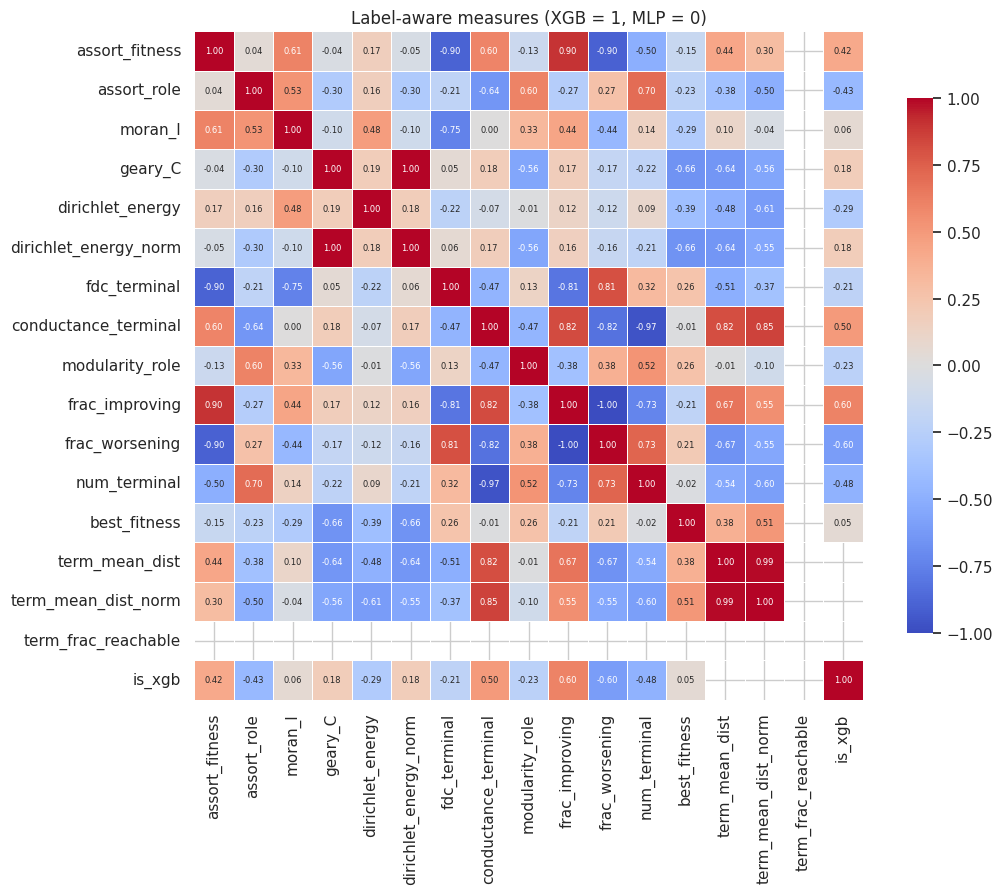

In [4]:
# Label-aware battery: small enough to show in full.
lab_cols = [c for c in LAB_COLS if c in num.columns]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num[lab_cols + ["is_xgb"]].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, annot=True, fmt=".2f",
            annot_kws={"size": 6}, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Label-aware measures (XGB = 1, MLP = 0)")
plt.tight_layout()

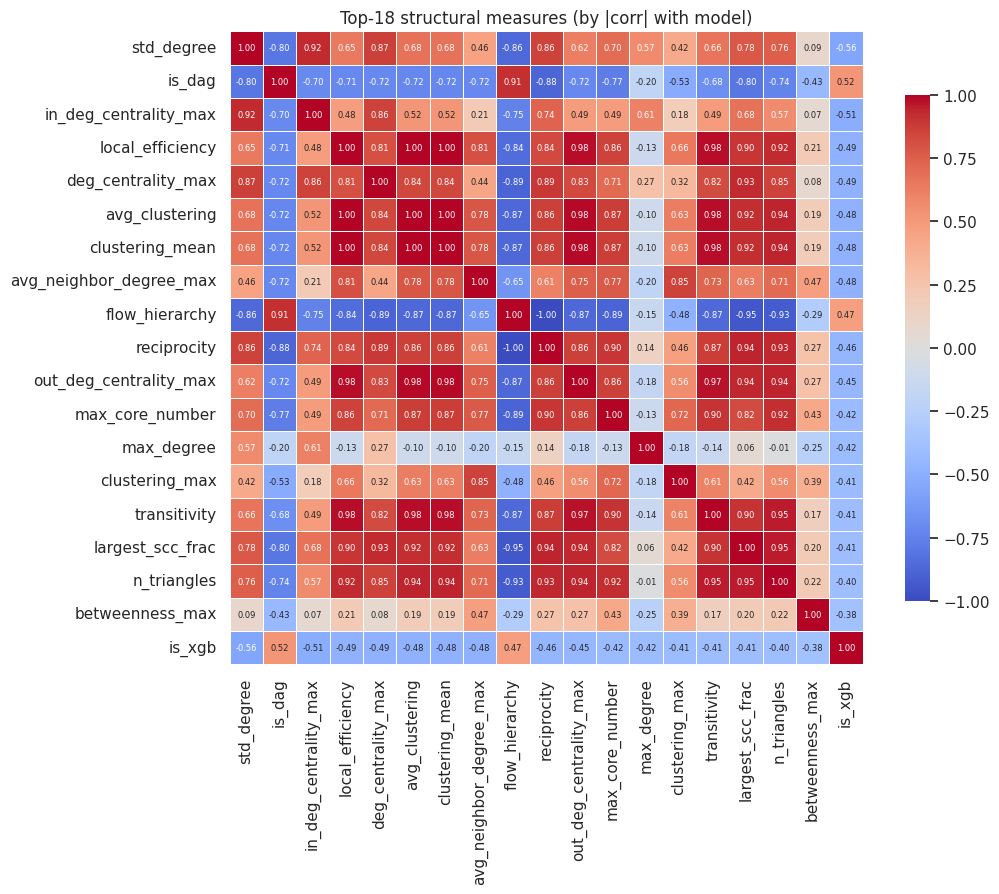

In [5]:
# Structural battery is large; show the measures most correlated with the model.
nx_cols = [c for c in model_corr.index if c not in lab_cols]
top_nx = model_corr.loc[nx_cols].abs().sort_values(ascending=False).head(18).index.tolist()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num[top_nx + ["is_xgb"]].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, annot=True, annot_kws={"size": 6},
            fmt=".2f", cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Top-18 structural measures (by |corr| with model)")
plt.tight_layout()

## Ranking across models — pooled

Each measure's point-biserial correlation with the model indicator (XGB = 1,
MLP = 0), ranked by absolute strength.

- (red) is higher under **XGB**,
- (green) is higher under **MLP**

,corr_with_xgb
frac_improving,0.603632
frac_worsening,-0.603632
std_degree,-0.556665
is_dag,0.522233
in_deg_centrality_max,-0.507915
conductance_terminal,0.495515
local_efficiency,-0.487269
deg_centrality_max,-0.486564
avg_clustering,-0.483589
clustering_mean,-0.483589


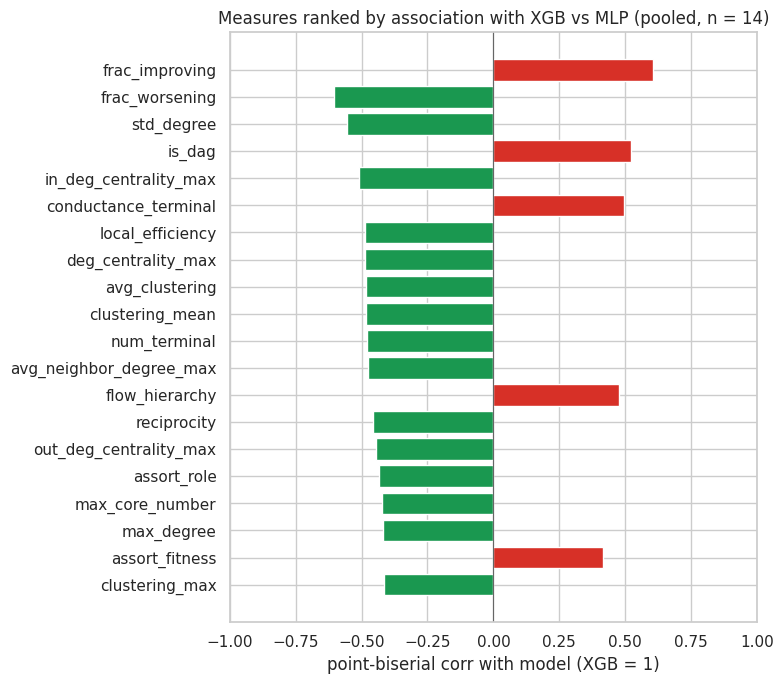

In [6]:
ranked = (model_corr.rename("corr_with_xgb").to_frame()
          .assign(abs_corr=lambda d: d["corr_with_xgb"].abs())
          .sort_values("abs_corr", ascending=False))

top = ranked.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d73027" if v > 0 else "#1a9850" for v in top["corr_with_xgb"]]
ax.barh(top.index, top["corr_with_xgb"], color=colors)
ax.axvline(0, color="0.4", lw=.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("point-biserial corr with model (XGB = 1)")
ax.set_title("Measures ranked by association with XGB vs MLP (pooled, n = 14)")
plt.tight_layout()
ranked.drop(columns="abs_corr").head(20)

## Paired study — dataset-controlled (Δ = XGB − MLP)

The pooled correlation ignores the dataset.  With only 7 datasets the right
design is the **paired** per-dataset contrast: for each measure and dataset,
Δ = XGB − MLP.  `sign_consistency` is the fraction of datasets that move the same
way (1.0 = every dataset agrees — the strongest evidence at small n); `effect_dz`
is the standardized paired effect (Cohen's d_z).  Sorted strongest-separating first.

In [7]:
def relabel_direction(study: pd.DataFrame, pos: str, neg: str) -> pd.DataFrame:
    """`paired_study` hardcodes 'real'/'random' in `direction`; map them to the models."""
    s = study.copy()
    s["direction"] = (s["direction"].str.replace("real", pos, regex=False)
                                    .str.replace("random", neg, regex=False))
    return s

# Drop label_type (constant 'real' string would break the numeric diff in paired_study).
mx = mlp_xgb.drop(columns="label_type")
study = relabel_direction(
    paired_study(mx, id_col="dataset", label_col="model", pos="XGB", neg="MLP"),
    "XGB", "MLP",
)
study.head(20)

,metric,n_pairs,mean_diff,direction,sign_consistency,effect_dz
0,frac_improving,7,0.166180,XGB>MLP,0.857143,0.994537
1,frac_worsening,7,-0.166180,XGB<MLP,0.857143,-0.994537
2,std_degree,7,-1.516337,XGB<MLP,0.857143,-0.898579
3,out_deg_centrality_max,7,-0.143308,XGB<MLP,0.857143,-0.786794
4,avg_neighbor_degree_mean,7,-1.028340,XGB<MLP,0.857143,-0.566591
5,assort_fitness,7,0.198874,XGB>MLP,0.857143,0.563529
6,mean_in_degree,7,-0.764575,XGB<MLP,0.857143,-0.553662
7,mean_out_degree,7,-0.764575,XGB<MLP,0.857143,-0.553662
8,mean_degree,7,-1.529151,XGB<MLP,0.857143,-0.553662
9,s_metric,7,-3466.142857,XGB<MLP,0.857143,-0.544039


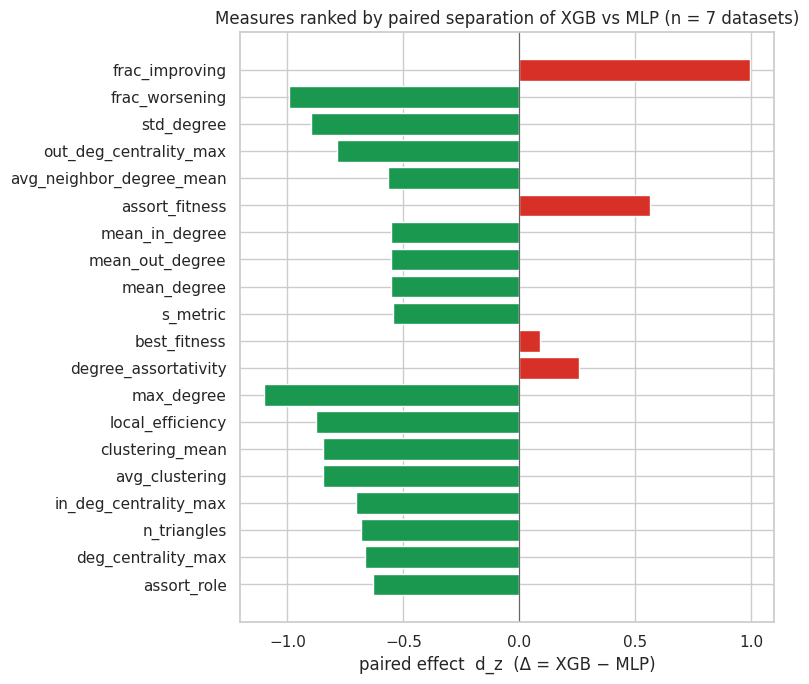

In [8]:
top = study.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d73027" if v > 0 else "#1a9850" for v in top["mean_diff"]]
ax.barh(top["metric"], top["effect_dz"], color=colors)
ax.axvline(0, color="0.4", lw=.8)
ax.set_xlabel("paired effect  d_z  (Δ = XGB − MLP)")
ax.set_title("Measures ranked by paired separation of XGB vs MLP (n = 7 datasets)")
plt.tight_layout()

## Bringing in SR (regression datasets only)

SR exists only for the 3 quantize (regression) datasets, so it can only be paired
with MLP / XGB there (n_pairs = 3).  At n = 3, `sign_consistency` is the readable
signal: 1.0 means all three datasets move the same way.  Top movers shown for
each contrast (Δ = SR − other).

In [9]:
sr_studies = {}
for other in ("MLP", "XGB"):
    sub = combined[combined["model"].isin(["SR", other])].drop(columns="label_type")
    st = relabel_direction(
        paired_study(sub, id_col="dataset", label_col="model", pos="SR", neg=other),
        "SR", other,
    )
    sr_studies[other] = st
    print(f"\n=== SR vs {other}  (Δ = SR − {other}, regression datasets) ===")
    display(st[st["sign_consistency"] == 1.0].head(15))


=== SR vs MLP  (Δ = SR − MLP, regression datasets) ===


,metric,n_pairs,mean_diff,direction,sign_consistency,effect_dz
0,num_terminal,3,19.666667,SR>MLP,1.0,12.874856
1,n_edges,3,137.333333,SR>MLP,1.0,7.041963
2,n_nodes,3,98.666667,SR>MLP,1.0,3.088868
3,best_fitness,3,-0.037807,SR<MLP,1.0,-2.776268
4,harmonic_max,3,20.807816,SR>MLP,1.0,2.732272
5,modularity_role,3,0.062545,SR>MLP,1.0,2.525507
6,wiener_index_lcc,3,34875.333333,SR>MLP,1.0,1.672032
7,pagerank_mean,3,-0.035474,SR<MLP,1.0,-1.644988
8,pagerank_max,3,-0.064127,SR<MLP,1.0,-1.470189
9,in_deg_centrality_max,3,-0.421770,SR<MLP,1.0,-1.384771



=== SR vs XGB  (Δ = SR − XGB, regression datasets) ===


,metric,n_pairs,mean_diff,direction,sign_consistency,effect_dz
0,num_terminal,3,22.333333,SR>XGB,1.0,19.341234
1,conductance_terminal,3,-0.349559,SR<XGB,1.0,-8.941068
2,avg_neighbor_degree_max,3,5.333333,SR>XGB,1.0,4.618802
3,fdc_terminal,3,0.149662,SR>XGB,1.0,3.685340
4,geary_C,3,0.189930,SR>XGB,1.0,3.627852
5,dirichlet_energy_norm,3,0.378530,SR>XGB,1.0,3.404030
6,assort_fitness,3,-0.281630,SR<XGB,1.0,-2.612724
7,harmonic_max,3,21.703042,SR>XGB,1.0,2.387242
8,frac_improving,3,-0.200193,SR<XGB,1.0,-2.127446
9,frac_worsening,3,0.200193,SR>XGB,1.0,2.127446


## Save

In [10]:
ranked.drop(columns="abs_corr").to_csv(METRICS_DIR / "pooled_model-corr.csv")
study.to_csv(METRICS_DIR / "pooled_paired_XGB-vs-MLP.csv", index=False)
for other, st in sr_studies.items():
    st.to_csv(METRICS_DIR / f"pooled_paired_SR-vs-{other}.csv", index=False)

print("wrote pooled_model-corr.csv, pooled_paired_XGB-vs-MLP.csv, "
      "pooled_paired_SR-vs-{MLP,XGB}.csv to", METRICS_DIR)

wrote pooled_model-corr.csv, pooled_paired_XGB-vs-MLP.csv, pooled_paired_SR-vs-{MLP,XGB}.csv to /home/agudeloacosta/HOMEdev/AE_paper/results/stn_30/metrics
